# <font color=blue> 기계학습 기초 4장: 회귀분석 (Linear Regression) </font>
###  Machine Learning and Bioinformatics (MLBI) Lab @ DKU, 2020.07.04 <br>

## 학습 목표
- 실제형/범주형 변수가 섞인 표 데이터를 회귀분석에 사용할 수 있게 전처리한다.
- 결측값 처리, one-hot encoding, train/test split의 역할을 이해한다.
- 집값 예측 모델의 성능과 feature importance를 해석한다.

## 사용할 데이터
- `load_data('house_price')`: House Prices 예제 데이터

## 직접 바꿔볼 것
- 결측값 처리 방식
- 사용할 회귀 모델
- GridSearchCV의 탐색 범위


In [1]:
# !pip install anndata
# !pip install mlbi-lab --upgrade

In [2]:
import math, os
import numpy as np
import pandas as pd
import sklearn.linear_model as lm
import sklearn.svm as svm
import sklearn.model_selection as mod_sel
import sklearn.metrics as met
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

from mlbi.datasets import load_data, load_anndata

/mnt/HDD2/Google_drive/PyPI_Git_Publish/pub_mlbi_lab/src/mlbi/datasets.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. 회귀분석을 위한 전처리


#### (1) 전처리 - csv 파일 불러와서 열기

#### (2) 특징 벡터와 목표값 설정

#### (3) regressor 정의

### House Price prediction
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

In [3]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


In [4]:
dct = load_data('house_price')
dct.keys()

INFO: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques


dict_keys(['DESCRIPTION', 'data'])

In [5]:
df_train = dct['data']
df_train.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df_train.shape

(1460, 80)

<Axes: >

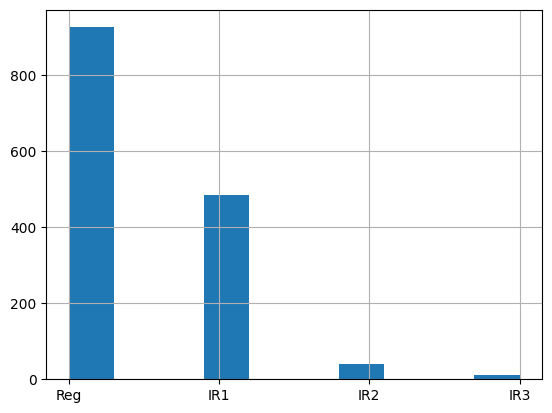

In [7]:
df_train['LotShape'].hist()

In [8]:
b = df_train.isnull()
df_train[b] = 'NA'

/tmp/ipykernel_411420/607979308.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_train[b] = 'NA'


In [9]:
cols = df_train.columns.values
n_classes = []
for c in cols:
    N = len(df_train[c].unique())
    n_classes.append(N)

n_cls = pd.Series(dict(zip(cols, n_classes)))
with pd.option_context('display.max_rows', None):
    display(n_cls)

MSSubClass         15
MSZoning            5
LotFrontage       111
LotArea          1073
Street              2
Alley               3
LotShape            4
LandContour         4
Utilities           2
LotConfig           5
LandSlope           3
Neighborhood       25
Condition1          9
Condition2          8
BldgType            5
HouseStyle          8
OverallQual        10
OverallCond         9
YearBuilt         112
YearRemodAdd       61
RoofStyle           6
RoofMatl            8
Exterior1st        15
Exterior2nd        16
MasVnrType          4
MasVnrArea        328
ExterQual           4
ExterCond           5
Foundation          6
BsmtQual            5
BsmtCond            5
BsmtExposure        5
BsmtFinType1        7
BsmtFinSF1        637
BsmtFinType2        7
BsmtFinSF2        144
BsmtUnfSF         780
TotalBsmtSF       721
Heating             6
HeatingQC           5
CentralAir          2
Electrical          6
1stFlrSF          753
2ndFlrSF          417
LowQualFinSF       24
GrLivArea 

In [10]:
values = {}
for c in cols:
    lst = np.array(df_train[c].unique())
    if len(lst) < 20:
        values[c] = lst

values

{'MSSubClass': array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
        180,  40]),
 'MSZoning': array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object),
 'Street': array(['Pave', 'Grvl'], dtype=object),
 'Alley': array(['NA', 'Grvl', 'Pave'], dtype=object),
 'LotShape': array(['Reg', 'IR1', 'IR2', 'IR3'], dtype=object),
 'LandContour': array(['Lvl', 'Bnk', 'Low', 'HLS'], dtype=object),
 'Utilities': array(['AllPub', 'NoSeWa'], dtype=object),
 'LotConfig': array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object),
 'LandSlope': array(['Gtl', 'Mod', 'Sev'], dtype=object),
 'Condition1': array(['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA',
        'RRNe'], dtype=object),
 'Condition2': array(['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe'],
       dtype=object),
 'BldgType': array(['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'], dtype=object),
 'HouseStyle': array(['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', '

In [11]:
cols

array(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'PavedDriv

In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1460 non-null   int64 
 1   MSZoning       1460 non-null   object
 2   LotFrontage    1460 non-null   object
 3   LotArea        1460 non-null   int64 
 4   Street         1460 non-null   object
 5   Alley          1460 non-null   object
 6   LotShape       1460 non-null   object
 7   LandContour    1460 non-null   object
 8   Utilities      1460 non-null   object
 9   LotConfig      1460 non-null   object
 10  LandSlope      1460 non-null   object
 11  Neighborhood   1460 non-null   object
 12  Condition1     1460 non-null   object
 13  Condition2     1460 non-null   object
 14  BldgType       1460 non-null   object
 15  HouseStyle     1460 non-null   object
 16  OverallQual    1460 non-null   int64 
 17  OverallCond    1460 non-null   int64 
 18  YearBuilt      1460 non-null   in

In [13]:
df_num = df_train.select_dtypes(include=[np.number])
df_num.columns.values

array(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'], dtype=object)

In [14]:
df_cat = df_train.select_dtypes(include=[object])
df_cat.columns.values

array(['MSZoning', 'LotFrontage', 'Street', 'Alley', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
       'MiscFeature', 'SaleType', 'SaleCondition'], dtype=object)

#### Set data

In [15]:
Stc = ['Pave', 'Grvl', 'NA', None]
Stv = [2, 1, 0, 0]
Stdict = dict(zip(Stc, Stv))

df_train['Street'] = df_train['Street'].replace(Stdict).astype(int)
df_train['Alley'] = df_train['Alley'].replace(Stdict).astype(int)

/tmp/ipykernel_411420/2865051524.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['Street'] = df_train['Street'].replace(Stdict).astype(int)
/tmp/ipykernel_411420/2865051524.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['Alley'] = df_train['Alley'].replace(Stdict).astype(int)


In [16]:
LSc = ['Reg', 'IR1', 'IR2', 'IR3', 'NA']
LSv = [3, 2, 1, 0, 0]
LSDict = dict(zip(LSc, LSv))

df_train['LotShape'] = df_train['LotShape'].replace(LSDict).astype(int)

/tmp/ipykernel_411420/2886926875.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['LotShape'] = df_train['LotShape'].replace(LSDict).astype(int)


In [17]:
Utc = ['AllPub', 'NoSewr', 'NoSeWa', 'ELO', 'NA']
Utv = [3, 2, 1, 0, 0]
Udict = dict(zip(Utc, Utv))

df_train['Utilities'] = df_train['Utilities'].replace(Udict).astype(int)

/tmp/ipykernel_411420/1522905738.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['Utilities'] = df_train['Utilities'].replace(Udict).astype(int)


In [18]:
Lslc = ['Gtl', 'Mod', 'Sev']
Lslv = [3, 2, 1]
LslDict = dict(zip(Lslc, Lslv))

df_train['LandSlope'] = df_train['LandSlope'].replace(LslDict).astype(int)

/tmp/ipykernel_411420/2346401372.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['LandSlope'] = df_train['LandSlope'].replace(LslDict).astype(int)


In [19]:
Quc = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
Quv = [5, 4, 3, 2, 1, 0]
Qdict = dict(zip(Quc, Quv))

df_train['ExterQual'] = df_train['ExterQual'].replace(Qdict).astype(int)
df_train['ExterCond'] = df_train['ExterCond'].replace(Qdict).astype(int)
df_train['BsmtQual'] = df_train['BsmtQual'].replace(Qdict).astype(int)
df_train['BsmtCond'] = df_train['BsmtCond'].replace(Qdict).astype(int)
df_train['HeatingQC'] = df_train['HeatingQC'].replace(Qdict).astype(int)
df_train['KitchenQual'] = df_train['KitchenQual'].replace(Qdict).astype(int)

df_train['FireplaceQu'] = df_train['FireplaceQu'].replace(Qdict).astype(int)
df_train['GarageQual'] = df_train['GarageQual'].replace(Qdict).astype(int)
df_train['GarageCond'] = df_train['GarageCond'].replace(Qdict).astype(int)
df_train['PoolQC'] = df_train['PoolQC'].replace(Qdict).astype(int)

/tmp/ipykernel_411420/2036739264.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['ExterQual'] = df_train['ExterQual'].replace(Qdict).astype(int)
/tmp/ipykernel_411420/2036739264.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['ExterCond'] = df_train['ExterCond'].replace(Qdict).astype(int)
/tmp/ipykernel_411420/2036739264.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [20]:
BEc = ['Gd', 'Av', 'Mn', 'No', 'NA']
BEv = [4, 3, 2, 1, 0]
BEdict = dict(zip(BEc, BEv))

df_train['BsmtExposure'] = df_train['BsmtExposure'].replace(BEdict).astype(int)

/tmp/ipykernel_411420/4023963612.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['BsmtExposure'] = df_train['BsmtExposure'].replace(BEdict).astype(int)


In [21]:
Fnc = ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'NA']
Fnv = [6, 5, 4, 3, 2, 1, 0, 0]
Fndict = dict(zip(Fnc, Fnv))

df_train['Functional'] = df_train['Functional'].replace(Fndict).astype(int)

/tmp/ipykernel_411420/3534999336.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['Functional'] = df_train['Functional'].replace(Fndict).astype(int)


In [22]:
CAc = ['Y', 'N', 'NA']
CAV = [1, 0, 0]
CADict = dict(zip(CAc, CAV))

df_train['CentralAir'] = df_train['CentralAir'].replace(CADict).astype(int)

/tmp/ipykernel_411420/729460255.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CentralAir'] = df_train['CentralAir'].replace(CADict).astype(int)


In [23]:
BFc = ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA']
BFv = [6, 5, 4, 3, 2, 1, 0]
BFdict = dict(zip(BFc, BFv))

df_train['BsmtFinType1'] = df_train['BsmtFinType1'].replace(BFdict).astype(int)
df_train['BsmtFinType2'] = df_train['BsmtFinType2'].replace(BFdict).astype(int)


/tmp/ipykernel_411420/3601339912.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['BsmtFinType1'] = df_train['BsmtFinType1'].replace(BFdict).astype(int)
/tmp/ipykernel_411420/3601339912.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['BsmtFinType2'] = df_train['BsmtFinType2'].replace(BFdict).astype(int)


In [24]:
Finc = ['Fin', 'RFn', 'Unf', 'NA']
Finv = [3, 2, 1, 0]
Fdict = dict(zip(Finc, Finv))

df_train['GarageFinish'] = df_train['GarageFinish'].replace(Fdict).astype(int)

/tmp/ipykernel_411420/205639791.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['GarageFinish'] = df_train['GarageFinish'].replace(Fdict).astype(int)


In [25]:
Pavc = ['Y', 'P', 'N', 'NA']
Pavv = [3, 2, 1, 0]
Pdict = dict(zip(Pavc, Pavv))

df_train['PavedDrive'] = df_train['PavedDrive'].replace(Pdict).astype(int)

/tmp/ipykernel_411420/4032619970.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['PavedDrive'] = df_train['PavedDrive'].replace(Pdict).astype(int)


In [26]:
Fnc = ['GdPrv', 'MnPrv', 'GdWo', 'MnWw', 'NA']
Fnv = [4, 3, 2, 1, 0]
Fndict = dict(zip(Fnc, Fnv))

df_train['Fence'] = df_train['Fence'].replace(Fndict).astype(int)

/tmp/ipykernel_411420/3685406553.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['Fence'] = df_train['Fence'].replace(Fndict).astype(int)


In [27]:
df_train['MoSold'] = df_train['MoSold'].astype(str)
df_train['MSSubClass'] = df_train['MSSubClass'].astype(str)

In [28]:
b = df_train['LotFrontage'] == 'NA'
df_train.loc[b, 'LotFrontage'] = 0
df_train['LotFrontage'] = df_train['LotFrontage'].astype(int)

b = df_train['MasVnrArea'] == 'NA'
df_train.loc[b, 'MasVnrArea'] = 0
df_train['MasVnrArea'] = df_train['MasVnrArea'].astype(int)

b = df_train['GarageYrBlt'] == 'NA'
df_train.loc[b, 'GarageYrBlt'] = df_train.loc[~b, 'GarageYrBlt'].min() - 10
df_train['GarageYrBlt'] = df_train['GarageYrBlt'].astype(int)


In [29]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1460 non-null   object
 1   MSZoning       1460 non-null   object
 2   LotFrontage    1460 non-null   int64 
 3   LotArea        1460 non-null   int64 
 4   Street         1460 non-null   int64 
 5   Alley          1460 non-null   int64 
 6   LotShape       1460 non-null   int64 
 7   LandContour    1460 non-null   object
 8   Utilities      1460 non-null   int64 
 9   LotConfig      1460 non-null   object
 10  LandSlope      1460 non-null   int64 
 11  Neighborhood   1460 non-null   object
 12  Condition1     1460 non-null   object
 13  Condition2     1460 non-null   object
 14  BldgType       1460 non-null   object
 15  HouseStyle     1460 non-null   object
 16  OverallQual    1460 non-null   int64 
 17  OverallCond    1460 non-null   int64 
 18  YearBuilt      1460 non-null   in

In [30]:
df_cat = df_train.select_dtypes(include=[object])
categorical_features = df_cat.columns.values
categorical_features

array(['MSSubClass', 'MSZoning', 'LandContour', 'LotConfig',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical',
       'GarageType', 'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition'],
      dtype=object)

In [31]:
values = {}
for c in categorical_features:
    lst = np.array(df_train[c].unique())
    values[c] = lst

values

{'MSSubClass': array(['60', '20', '70', '50', '190', '45', '90', '120', '30', '85', '80',
        '160', '75', '180', '40'], dtype=object),
 'MSZoning': array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object),
 'LandContour': array(['Lvl', 'Bnk', 'Low', 'HLS'], dtype=object),
 'LotConfig': array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object),
 'Neighborhood': array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
        'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
        'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
        'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
        'Blueste'], dtype=object),
 'Condition1': array(['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA',
        'RRNe'], dtype=object),
 'Condition2': array(['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe'],
       dtype=object),
 'BldgType': array(['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'], d

In [32]:
values = {}
for c in cols:
    if c not in categorical_features:
        lst = np.array(df_train[c].unique())
        if len(lst) < 20:
            values[c] = lst

values

{'Street': array([2, 1]),
 'Alley': array([0, 1, 2]),
 'LotShape': array([3, 2, 1, 0]),
 'Utilities': array([3, 1]),
 'LandSlope': array([3, 2, 1]),
 'OverallQual': array([ 7,  6,  8,  5,  9,  4, 10,  3,  1,  2]),
 'OverallCond': array([5, 8, 6, 7, 4, 2, 3, 9, 1]),
 'ExterQual': array([4, 3, 5, 2]),
 'ExterCond': array([3, 4, 2, 1, 5]),
 'BsmtQual': array([4, 3, 5, 0, 2]),
 'BsmtCond': array([3, 4, 0, 2, 1]),
 'BsmtExposure': array([1, 4, 2, 3, 0]),
 'BsmtFinType1': array([6, 5, 1, 3, 4, 0, 2]),
 'BsmtFinType2': array([1, 4, 0, 5, 3, 2, 6]),
 'HeatingQC': array([5, 4, 3, 2, 1]),
 'CentralAir': array([1, 0]),
 'BsmtFullBath': array([1, 0, 2, 3]),
 'BsmtHalfBath': array([0, 1, 2]),
 'FullBath': array([2, 1, 3, 0]),
 'HalfBath': array([1, 0, 2]),
 'BedroomAbvGr': array([3, 4, 1, 2, 0, 5, 6, 8]),
 'KitchenAbvGr': array([1, 2, 3, 0]),
 'KitchenQual': array([4, 3, 5, 2]),
 'TotRmsAbvGrd': array([ 8,  6,  7,  9,  5, 11,  4, 10, 12,  3,  2, 14]),
 'Functional': array([6, 5, 2, 4, 3, 1, 0]),
 '

In [33]:
## Onehot encoding for categorical features
def onehot_encoding( df, catf_lst ):
    for c in catf_lst:
        df_tmp = pd.get_dummies(df[c], prefix = c)
        df = pd.concat([df, df_tmp], axis = 1)
        df = df.drop(c, axis = 1)
    return df

In [34]:
df_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65,8450,2,0,3,Lvl,3,Inside,...,0,0,0,NA,0,2,2008,WD,Normal,208500
2,20,RL,80,9600,2,0,3,Lvl,3,FR2,...,0,0,0,NA,0,5,2007,WD,Normal,181500
3,60,RL,68,11250,2,0,2,Lvl,3,Inside,...,0,0,0,NA,0,9,2008,WD,Normal,223500
4,70,RL,60,9550,2,0,2,Lvl,3,Corner,...,0,0,0,NA,0,2,2006,WD,Abnorml,140000
5,60,RL,84,14260,2,0,2,Lvl,3,FR2,...,0,0,0,NA,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62,7917,2,0,3,Lvl,3,Inside,...,0,0,0,NA,0,8,2007,WD,Normal,175000
1457,20,RL,85,13175,2,0,3,Lvl,3,Inside,...,0,0,3,NA,0,2,2010,WD,Normal,210000
1458,70,RL,66,9042,2,0,3,Lvl,3,Inside,...,0,0,4,Shed,2500,5,2010,WD,Normal,266500


In [35]:
df = df_train.copy(deep = True)
df = onehot_encoding(df, categorical_features)
df.head()

,LotFrontage,LotArea,Street,Alley,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,65,8450,2,0,3,3,3,7,5,2003,...,False,False,False,True,False,False,False,False,True,False
2,80,9600,2,0,3,3,3,6,8,1976,...,False,False,False,True,False,False,False,False,True,False
3,68,11250,2,0,2,3,3,7,5,2001,...,False,False,False,True,False,False,False,False,True,False
4,60,9550,2,0,2,3,3,7,5,1915,...,False,False,False,True,True,False,False,False,False,False
5,84,14260,2,0,2,3,3,8,5,2000,...,False,False,False,True,False,False,False,False,True,False


In [36]:
df.columns.values

array(['LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape',
       'Utilities', 'LandSlope', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', 'CentralAir', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
       '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence',
       'MiscVal', 'YrSold', 'SalePrice', 'MSSubClass_120',
       'MSSubClass_160', 'MSSubClass_180', 'MSSubClass_190',
       'MSSubClass_20', 'MSSubC

In [37]:
df.isnull().sum().sum()

0

In [38]:
X = df.drop(columns = 'SalePrice')
X = (X - X.mean())/X.std()  ## z-score normalization
y = np.log(df['SalePrice'])

<Axes: >

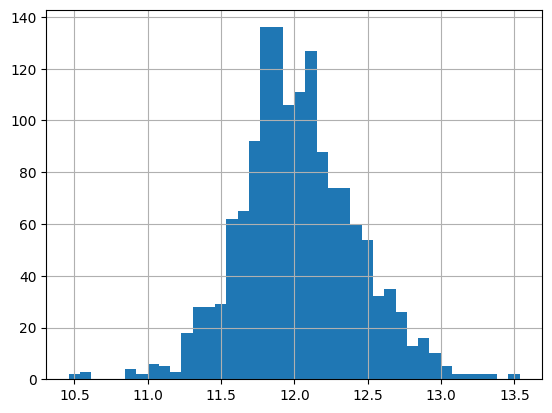

In [39]:
y.hist(bins = 40)

In [40]:
X_2d = TSNE(learning_rate=300, init='pca').fit_transform(X)

In [41]:
df_2d = pd.DataFrame(X_2d, columns = ['D1', 'D2'], index = X.index.values)
df_2d['label'] = y.astype(float)

In [42]:
df_2d

,D1,D2,label
1,0.623079,29.250710,12.247694
2,-21.718138,-12.087199,12.109011
3,1.974446,27.089890,12.317167
4,20.476866,-44.795147,11.849398
5,-41.861580,23.932663,12.429216
...,...,...,...
1456,13.644498,23.283241,12.072541
1457,-6.461152,0.216794,12.254863
1458,28.077320,-28.038771,12.493130
1459,-3.187116,-26.111746,11.864462


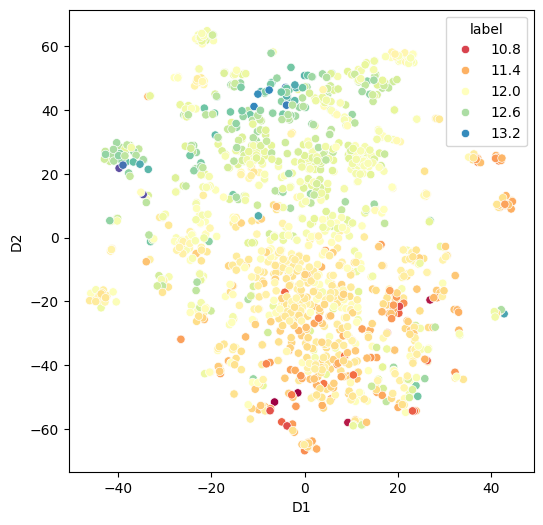

In [43]:
plt.figure(figsize = (6,6))
sns.scatterplot(data = df_2d, x = 'D1', y = 'D2',
                hue = 'label', palette = 'Spectral')
plt.show()

## Model to use: Linear regression model
__Model description:__ https://scikit-learn.org/stable/modules/linear_model.html
#### __Model:__&nbsp;     $ \hat{y_i} = {\bf x} ^T_i {\boldsymbol{\theta}} + \theta_0 $ &nbsp;&nbsp;&nbsp;  <img src="https://drive.google.com/uc?export=view&id=1xfUKhXll9CQGJxXIK1JatYlAAz7RLWyp" align="center" width="150"/>
<div>
<img src="attachment:linear_reg.png" width="150"/>
</div>

#### __Cost to minimize:__ &nbsp;     $ \min_{{\boldsymbol{\theta}},\theta_0} \sum^{n}_{i=1} \left( {\bf x} ^T_i {\boldsymbol{\theta}} + \theta_0  - y_i \right)^2 $

__Function description:__ https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


#### Set linear regressor and its parameters to use for regression

In [69]:
#########################################################
## (3) Set linear regressor and its parameters to use

## Plain Linear Model (Ordinary Least Squares)
regressor = lm.LinearRegression( fit_intercept = True )
param_default = regressor.get_params()
print('Default hyper parameters: ', param_default)

# ## set a few parameters for linear regressor
# param = {'fit_intercept':True }

# ## initialize Model
# regressor.set_params(**param)

Default hyper parameters:  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


####  Alternative: MultiTaskElasticNet regressor

In [45]:
## MultiTaskElasticNet regressor and its parameters to use
regressor = lm.ElasticNet()

## set a few parameters for linear regressor
param = {'alpha': 0.01, 'l1_ratio': 1, 'fit_intercept':True }

## initialize Model
regressor.set_params(**param)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.01
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


#### Alternative: SVR regressor

In [46]:
## SVR regressor and its parameters to use
regressor = svm.SVR()
param_default = regressor.get_params()

## set a few parameters for SVM regressor, SVR
param = {'kernel': 'linear', 'C': 10, 'gamma':'auto' }

## initialize Model
regressor.set_params(**param)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


#### Other regressors available online: https://scikit-learn.org/0.21/supervised_learning.html#supervised-learning

## 2. 기본 학습 절차

<img src="https://drive.google.com/uc?export=view&id=1oKGKJawQMry5LoLKNNyLQZYcx82VQtro" align="center" width="600"/>
<div>
<div>
<img src="attachment:train_test.jpg" width="500"/>
</div>

#### (1) 데이터를 학습데이터와 테스트 데이터로 분리

#### (2) 학습 수행(fit)

#### (3) 테스트 수행 (predict)

#### (4) 성능/결과 확인

In [47]:
X.shape, y.shape

((1460, 247), (1460,))

In [48]:
#########################################################
## 2. Regression example: Naive implementation

## (1) Divide data for traning (70%) and test (30%)
X_train, X_test, y_train, y_test = mod_sel.train_test_split(X, y, test_size=0.2, random_state=0)

In [49]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1168, 247), (1168,), (292, 247), (292,))

In [50]:
X_train

,LotFrontage,LotArea,Street,Alley,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
619,0.934007,0.117938,0.064216,-0.242942,0.701051,0.026171,0.225639,2.097391,-0.517023,1.183071,...,-0.058601,3.310544,-0.045361,-2.561302,-0.272522,-0.052396,-0.091003,-0.117811,-2.137613,3.266908
871,0.068564,-0.392418,0.064216,-0.242942,0.701051,0.026171,0.225639,-0.794879,-0.517023,-0.306852,...,-0.058601,-0.301858,-0.045361,0.390159,-0.272522,-0.052396,-0.091003,-0.117811,0.467491,-0.305890
93,0.645526,0.284851,0.064216,2.444142,-1.016288,0.026171,0.225639,-0.794879,1.280247,-1.664337,...,-0.058601,-0.301858,-0.045361,0.390159,-0.272522,-0.052396,-0.091003,-0.117811,0.467491,-0.305890
818,-1.662324,0.275333,0.064216,-0.242942,-1.016288,0.026171,0.225639,1.374324,-0.517023,1.017524,...,-0.058601,-0.301858,-0.045361,0.390159,-0.272522,-0.052396,-0.091003,-0.117811,0.467491,-0.305890
303,1.741755,0.319315,0.064216,-0.242942,-1.016288,0.026171,0.225639,0.651256,-0.517023,0.984415,...,-0.058601,-0.301858,-0.045361,0.390159,-0.272522,-0.052396,-0.091003,-0.117811,0.467491,-0.305890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764,0.703222,-0.108887,0.064216,-0.242942,0.701051,0.026171,0.225639,1.374324,-0.517023,0.918196,...,-0.058601,-0.301858,-0.045361,0.390159,-0.272522,-0.052396,-0.091003,-0.117811,0.467491,-0.305890
836,0.068564,-0.091855,0.064216,-0.242942,0.701051,0.026171,0.225639,-1.517947,1.280247,-0.704164,...,-0.058601,-0.301858,-0.045361,0.390159,-0.272522,-0.052396,-0.091003,-0.117811,0.467491,-0.305890
1217,0.299349,-0.158981,0.064216,-0.242942,0.701051,0.026171,0.225639,-0.071812,-0.517023,0.222899,...,-0.058601,-0.301858,-0.045361,0.390159,-0.272522,-0.052396,-0.091003,-0.117811,0.467491,-0.305890


In [51]:
## (2) Fit model to the data, X_train and y_train
regressor.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [52]:
regressor.intercept_, regressor.coef_

(array([12.0265]),
 array([[ 5.40612529e-03,  2.08425840e-02,  3.31736290e-03,
          8.35932071e-03, -3.36604384e-03,  3.07420197e-03,
          5.92137396e-03,  5.83718935e-02,  3.59941878e-02,
          4.03725651e-02,  5.22555424e-03,  6.02032327e-03,
          3.40686052e-03, -2.82908074e-03,  2.13629593e-03,
         -1.54202963e-03,  1.61167417e-02,  1.17338808e-02,
          2.38851142e-02, -2.62404339e-03,  6.35682087e-03,
          7.58373522e-03,  3.48079539e-02,  1.48936345e-02,
          2.68237681e-02,  3.99781856e-02,  5.03181021e-02,
          5.31460629e-03,  7.17034784e-02,  1.82710437e-02,
         -1.02534070e-03,  1.78508098e-02,  2.21638531e-02,
         -6.69279766e-03, -5.78403117e-03,  1.65593166e-02,
          1.57691428e-02,  1.28756731e-02,  1.26005757e-02,
          7.76546199e-04, -1.81914613e-02,  1.67245647e-03,
          1.63167632e-02,  2.61764243e-02,  4.17401674e-02,
         -1.86590892e-02,  3.15229640e-03,  9.15350046e-03,
          3.07466790e

In [53]:
regressor.intercept_, regressor.coef_

(array([12.0265]),
 array([[ 5.40612529e-03,  2.08425840e-02,  3.31736290e-03,
          8.35932071e-03, -3.36604384e-03,  3.07420197e-03,
          5.92137396e-03,  5.83718935e-02,  3.59941878e-02,
          4.03725651e-02,  5.22555424e-03,  6.02032327e-03,
          3.40686052e-03, -2.82908074e-03,  2.13629593e-03,
         -1.54202963e-03,  1.61167417e-02,  1.17338808e-02,
          2.38851142e-02, -2.62404339e-03,  6.35682087e-03,
          7.58373522e-03,  3.48079539e-02,  1.48936345e-02,
          2.68237681e-02,  3.99781856e-02,  5.03181021e-02,
          5.31460629e-03,  7.17034784e-02,  1.82710437e-02,
         -1.02534070e-03,  1.78508098e-02,  2.21638531e-02,
         -6.69279766e-03, -5.78403117e-03,  1.65593166e-02,
          1.57691428e-02,  1.28756731e-02,  1.26005757e-02,
          7.76546199e-04, -1.81914613e-02,  1.67245647e-03,
          1.63167632e-02,  2.61764243e-02,  4.17401674e-02,
         -1.86590892e-02,  3.15229640e-03,  9.15350046e-03,
          3.07466790e

In [54]:
## (3) Performance test
y_pred = regressor.predict(X_test)
y_pred_train = regressor.predict(X_train)

In [55]:
y_pred, np.array(y_test)

(array([12.52104482, 11.78519147, 11.74204453, 12.32968664, 11.45427573,
        11.41393024, 12.49552124, 11.82543825, 13.43839969, 11.96790308,
        12.19967178, 11.86326809, 12.39680265, 11.70751814, 11.67704956,
        11.87618823, 12.29489108, 11.7346038 , 11.8820263 , 12.10463412,
        11.67305113, 12.10764452, 11.35697886, 11.94706741, 12.18592849,
        12.00446186, 11.96371613, 11.2416891 , 12.58819068, 11.61076028,
        12.02076706, 12.2246048 , 11.99010905, 12.62719301, 12.80718924,
        12.16495739, 12.49661425, 11.70265389, 12.30446013, 12.68042276,
        12.24830841, 11.69878214, 12.19398927, 12.68623389, 12.78922742,
        11.83632423, 11.55347449, 11.70221117, 12.02826449, 11.50820891,
        12.94827092, 11.96214883, 11.99877035, 11.36458129, 12.33940556,
        11.65146343, 11.60721821, 12.38745184, 11.81554413, 11.26121628,
        11.89464661, 11.8124612 , 11.78604457, 11.95557474, 12.20861932,
        12.07242481, 11.74813442, 12.232048  , 11.8

In [56]:
regressor.score(X_train, y_train), regressor.score(X_test, y_test)

(0.9438683952597187, 0.7000149914501672)

In [57]:
from scipy.stats import pearsonr

In [58]:
## (4) Check Performance
# mse = ((y_test - y_pred)**2).mean()
mse = met.mean_squared_error(y_test, y_pred)
mse_norm = mse/y_test.var()
exp_var = ((y_pred-y_test.mean())**2).mean()/((y_test-y_test.mean())**2).mean()
r_square = 1 - mse_norm
pc, pv = pearsonr(y_test, y_pred)

# mse_train = ((y_train - y_pred_train)**2).mean()
mse_train = met.mean_squared_error(y_train, y_pred_train)
mse_norm_train = mse_train/y_train.var()
exp_var_train = ((y_pred_train-y_train.mean())**2).mean()/((y_train-y_train.mean())**2).mean()
r_square_train = 1 - mse_norm_train
pc_train, pv_train = pearsonr(y_train, y_pred_train)

print( "Normalized.MSE = %f, %f" % (round(mse_norm,4), round(mse_norm_train,4)) )
print( "R2 = %f, %f" % (round(r_square,4), round(r_square_train,4)) )
print( "Explained Var. = %f, %f" % (round(exp_var,4), round(exp_var_train,4)) )
print( "PC = %f, %f" % (round(pc,4), round(pc_train,4)) )


Normalized.MSE = 0.299000, 0.056100
R2 = 0.701000, 0.943900
Explained Var. = 1.175800, 0.955500
PC = 0.865000, 0.971600


#### Scatter plot 확인

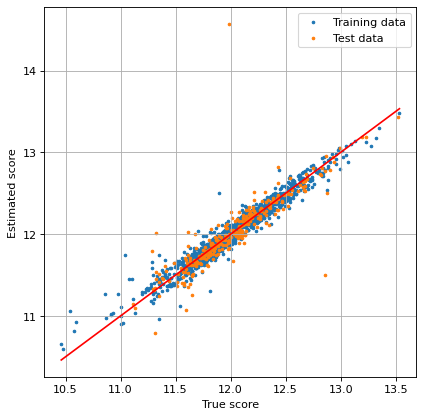

In [59]:
## (7) Scatter plot
plt.figure(num=None, figsize=(6, 6), dpi=80)

plt.scatter(y_train,y_pred_train, s = 5)
plt.scatter(y_test,y_pred, s = 5)
xp = [min(y), max(y)]
yp = xp
plt.plot(xp,yp,'r-')
plt.xlabel('True score')
plt.ylabel('Estimated score')
plt.grid()
plt.legend(['Training data', 'Test data'])
plt.show()


## 4. 교차 검증

<img src="https://drive.google.com/uc?export=view&id=18ir-c1MLL6mDi9wJdMK7BegtqRgvQt_X" align="center" width="800"/>
<div>
<div>
<img src="attachment:cross_val.jpg" width="800"/>
</div>

#### sklearn.model_selection 모듈의 .cross_val_score 사용
#### 또는 sklearn.model_selection 모듈의 .cross_val_predict 사용

In [60]:
from sklearn.model_selection import KFold # Import KFold
#########################################################
## 3. Regression example: Cross-validation

## Set parameters for cross-validation
NCV = KFold(n_splits=10, shuffle=True, random_state=0) # Use KFold for regression

## Performance test
cv_scores = mod_sel.cross_val_score(regressor, X, y, \
                                    scoring='r2',
                                    cv=NCV, n_jobs = 4)

score = cv_scores.mean() ## Normalized MSE
print( "R2 (CV) = " + str(round(score,4)) )

/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11

R2 (CV) = 0.8583


In [61]:
cv_scores

array([0.85650916, 0.54858252, 0.93479919, 0.87577513, 0.79526949,
       0.91438157, 0.89876084, 0.92996149, 0.92079682, 0.90824397])

In [62]:
## Performance test
y_pred_cv = mod_sel.cross_val_predict(regressor, X, y, \
                                      cv=NCV, n_jobs = 4)

In [63]:
y_pred_cv

array([12.22388901, 12.22312313, 12.26635937, ..., 12.57785754,
       11.88409074, 11.93158884])

In [64]:
from scipy.stats import pearsonr

In [65]:
mse = met.mean_squared_error(y, y_pred_cv)
mse_norm = mse/y.var()
exp_var = ((y_pred_cv-y.mean())**2).mean()/((y-y_pred_cv.mean())**2).mean()
r_square = 1 - mse_norm
pc, pv = pearsonr(y, y_pred_cv)

print( "Normalized.MSE = %f" % (round(mse_norm,4) ))
print( "R2 = %f" % (round(r_square,4) ))
print( "Explained Var. = %f" % (round(exp_var,4) ))
print( "PC = %f" % (round(pc,4) ))


Normalized.MSE = 0.142700
R2 = 0.857300
Explained Var. = 1.005000
PC = 0.929000


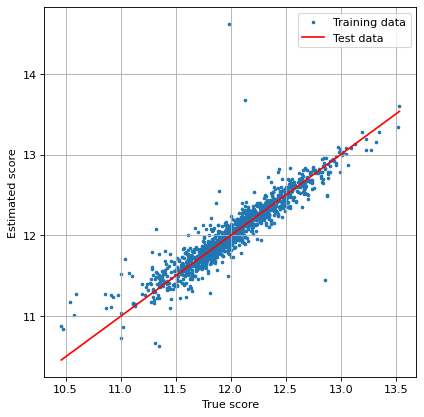

In [66]:
## (7) Scatter plot
plt.figure(num=None, figsize=(6, 6), dpi=80)

plt.scatter(y,y_pred_cv, s = 5)
xp = [min(y), max(y)]
yp = xp
plt.plot(xp,yp,'r-')
plt.xlabel('True score')
plt.ylabel('Estimated score')
plt.grid()
plt.legend(['Training data', 'Test data'])
plt.show()


#### 다른 성능 지표들

## 5. 그리드 탐색을 이용한 하이퍼 파라미터 최적화

#### (1) 파라미터 그리드 설정

#### (2) sklearn.model_selection 모듈의 .GridSearchCV 사용

#### (3) 베스트 파라미터 추출

#### (4) 베스트 파라미터를 이용한 성능 (재) 평가

In [70]:
if isinstance(regressor, lm.LinearRegression):
    ## (1) set parameter grid for linear regressor
    param_grid = { 'fit_intercept': [True, False], 'positive': [True, False] }

elif isinstance(regressor, lm.ElasticNet):
    ## (1) set parameter grid for ElasticNet regressor
    param_grid = { 'fit_intercept': [True], 'positive': [False],
                'alpha': [0.5, 0.2, 0.1, 0.03, 0.01, 0.005],
                'l1_ratio': [0, 0.25, 0.5, 1]}

elif isinstance(regressor, svm.SVR):
    ## (1) set parameter grid for SVR regressor
    param_grid = { 'kernel': ['linear', 'poly', 'rbf'],
                'degree': [2, 3],
                'C': [1, 10, 100, 200, 400],
                'gamma': ['scale'], #, 'auto'],
                'shrinking': [True]}

In [71]:
#########################################################
## (3) Regression example: Parameter Optimization (grid search)

## Set parameters for cross-validation
NCV = KFold(n_splits=10, shuffle=True, random_state=0)

## (2) Search grid to find best parameters
reg = mod_sel.GridSearchCV(regressor, param_grid, cv=NCV, scoring='r2', n_jobs = 4)
reg.fit(X,y)

## (3) Get best paramter
best_param = reg.best_params_
print("Best Scroe(R2): %5.2f with parameters " % (reg.best_score_), end='' )
print(reg.best_params_)


/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11

Best Scroe(R2):  0.85 with parameters {'fit_intercept': True, 'positive': False}


In [72]:
reg.best_estimator_.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [73]:
reg.best_estimator_

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
## (4) Performance test using the best parameters
# regressor.set_params( **best_param )
regressor = reg.best_estimator_
cv_scores = mod_sel.cross_val_score(regressor, X, y, scoring='r2', cv=NCV, verbose = 0)
score = cv_scores.mean()
print( "R2 = " + str(round(score,4)) + "\n" )

y_pred_cv = mod_sel.cross_val_predict(regressor, X, y, cv=NCV)


R2 = 0.853



In [75]:
y_log = y # np.log10(y)
y_pred_cv_log = y_pred_cv # np.log(y_pred_cv)

mse = met.mean_squared_error(y_log, y_pred_cv_log)
mse_norm = mse/y_log.var()
exp_var = ((y_pred_cv_log-y_log.mean())**2).mean()/((y_log-y_pred_cv_log.mean())**2).mean()
r_square = met.r2_score(y_log, y_pred_cv_log) # 1 - mse_norm
pc, pv = pearsonr(y_log, y_pred_cv_log)

print( "Root.MSE = %f" % (round(np.sqrt(mse),4) ))
print( "Normalized.MSE = %f" % (round(mse_norm,4) ))
print( "R2 = %f" % (round(r_square,4) ))
print( "Explained Var. = %f" % (round(exp_var,4) ))
print( "PC = %f" % (round(pc,4) ))

Root.MSE = 0.153900
Normalized.MSE = 0.148400
R2 = 0.851500
Explained Var. = 0.994900
PC = 0.925600


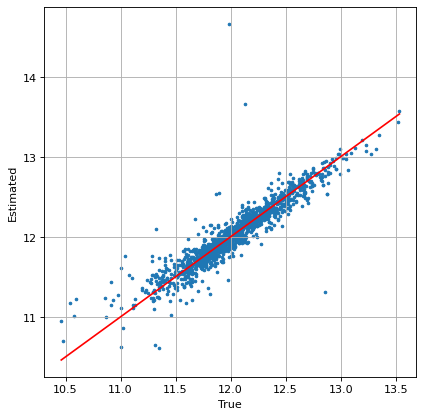

In [76]:
plt.figure(num=None, figsize=(6, 6), dpi=80)

plt.scatter(y_log,y_pred_cv_log, s = 5)
xp = [min(y), max(y)]
yp = xp
plt.plot(xp,yp,'r-')
plt.xlabel('True')
plt.ylabel('Estimated')
plt.grid()
plt.show()

#### Find Feature importance

In [77]:
reg.best_estimator_.coef_

array([ 3.19155852e-03,  1.87883455e-02,  4.15254254e-03,  5.41234404e-03,
        2.81873902e-04,  7.38543683e-03,  8.30011730e-04,  5.82996112e-02,
        3.80428878e-02,  5.20547520e-02,  1.17137110e-02,  6.19385259e-03,
        1.96470991e-04, -4.16499466e-03,  6.73709294e-03,  1.42103884e-03,
        1.23059609e-02,  7.86072432e-03,  2.67465182e-02, -2.55591561e-03,
        5.82098823e-03, -7.02591704e-04,  2.92397213e-02,  1.42671501e-02,
        1.53368069e-02,  4.36890317e-02,  3.98220858e-02,  4.64997598e-03,
        6.56527132e-02,  1.30484789e-02,  1.82967005e-03,  1.69043554e-02,
        1.51254111e-02, -1.85806356e-03, -9.64790599e-03,  1.46060562e-02,
        1.20242578e-02,  2.12445435e-02,  9.18882725e-03,  7.19007205e-03,
       -1.00447704e-02,  5.40425015e-03,  1.73760538e-02,  2.62842420e-02,
        2.78070549e-02, -4.60260587e-03,  4.62437345e-03,  1.12208725e-02,
        4.63781371e-03,  6.39042811e-03,  5.39389206e-03,  1.63633382e-02,
        1.19978817e-02, -

In [78]:
reg.best_params_

{'fit_intercept': True, 'positive': False}

In [79]:
## MultiTaskElasticNet regressor and its parameters to use
regressor = lm.ElasticNet()

## set a few parameters for linear regressor
# param = reg.best_params_
param = {'alpha': 0.01, 'l1_ratio': 1, 'fit_intercept':True }

## initialize Model
regressor.set_params(**param)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.01
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [80]:
## (2) Fit model to the data, X_train and y_train
regressor.fit(X,y)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.01
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [81]:
regressor.coef_

array([ 0.        ,  0.01423773,  0.        ,  0.        , -0.        ,
        0.        , -0.        ,  0.09031345,  0.02570382,  0.0339588 ,
        0.0158732 ,  0.        ,  0.0095926 ,  0.        ,  0.01089967,
        0.        ,  0.00968164,  0.00716527,  0.02246572,  0.        ,
        0.        , -0.        ,  0.03038405,  0.01135945,  0.01177495,
        0.00551559,  0.        , -0.        ,  0.12311982,  0.00597878,
        0.        ,  0.        ,  0.        ,  0.        , -0.        ,
        0.01754472,  0.        ,  0.0121916 ,  0.00907748,  0.01177854,
        0.        ,  0.00917697,  0.02591728,  0.02182036,  0.        ,
        0.        ,  0.00025756,  0.00474767,  0.        , -0.        ,
        0.        ,  0.00525605,  0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.00383462, -0.        ,
       -0.        ,  0.        , -0.00754698, -0.        , -0.        ,
       -0.        ,  0.        ,  0.        , -0.        ,  0.  

In [82]:
Coefs = pd.DataFrame( {'coefs': regressor.coef_}, index = X.columns )
Coefs['abs_coefs'] = np.abs(Coefs['coefs'])

with pd.option_context('display.max_rows', None):
    display( Coefs.sort_values(by = 'abs_coefs', ascending = False) )

,coefs,abs_coefs
GrLivArea,0.123120,0.123120
OverallQual,0.090313,0.090313
RoofMatl_ClyTile,-0.052473,0.052473
YearBuilt,0.033959,0.033959
TotalBsmtSF,0.030384,0.030384
GarageCars,0.025917,0.025917
OverallCond,0.025704,0.025704
MSZoning_RM,-0.023738,0.023738
MSZoning_C (all),-0.023569,0.023569
BsmtFinSF1,0.022466,0.022466
